## Reporte de Control de Gestión - Cierre Anual

Este notebook genera un reporte visual de control de gestión anual, comparando ingresos reales con el presupuesto y analizando el desvío presupuestario por división.

In [1]:
# Importar las librerías necesarias para la creación de gráficos.
import matplotlib.pyplot as plt
import numpy as np

### 1. Preparación de los Datos Simulados

Se definen los datos que se utilizarán para generar los gráficos. Estos incluyen meses, ingresos reales, presupuesto y el desvío por división.

Para un enfoque más pedagógico y alineado con el análisis de datos moderno, transformaremos los datos en un `DataFrame` de pandas. Esto facilita la manipulación y el análisis posterior de los datos.

**Elementos clave del código:**

*   `pd.DataFrame({'Columna': lista_datos})`: Crea un DataFrame a partir de un diccionario donde las claves son los nombres de las columnas y los valores son las listas de datos.
*   `df.head()`: Muestra las primeras 5 filas del DataFrame, lo cual es útil para una inspección rápida de los datos cargados.

In [2]:
meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
ingresos_reales = [120, 135, 150, 145, 160, 180, 175, 190, 210, 220, 230, 250]
presupuesto = [115, 130, 140, 150, 155, 170, 170, 180, 200, 210, 220, 240]

divisiones = ['Norte', 'Sur', 'Este', 'Oeste']
desvio_presupuesto = [5.2, -2.1, 8.4, -0.5] # Porcentajes

In [9]:
import pandas as pd

# Crear un DataFrame para los ingresos reales y presupuesto
df_ingresos = pd.DataFrame({
    'Mes': meses,
    'Real': ingresos_reales,
    'Presupuesto': presupuesto
})

# Mostrar el encabezado del DataFrame de ingresos
display(df_ingresos.head())

,Mes,Real,Presupuesto
0,Ene,120,115
1,Feb,135,130
2,Mar,150,140
3,Abr,145,150
4,May,160,155


### 2. Configuración de Estilo Global

Se establece un estilo visual para todos los gráficos, intentando usar `seaborn-v0_8-whitegrid` y cayendo a `ggplot` si no está disponible.

In [3]:
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('ggplot') # Fallback por si la versión de matplotlib varía

### 3. Creación del Lienzo (Figure) y Sub-gráficos (Axes)

Se inicializa la figura principal y se crean dos sub-gráficos (axes) apilados verticalmente para diferentes visualizaciones.

Text(0.5, 0.98, 'Reporte de Control de Gestión - Cierre Anual')

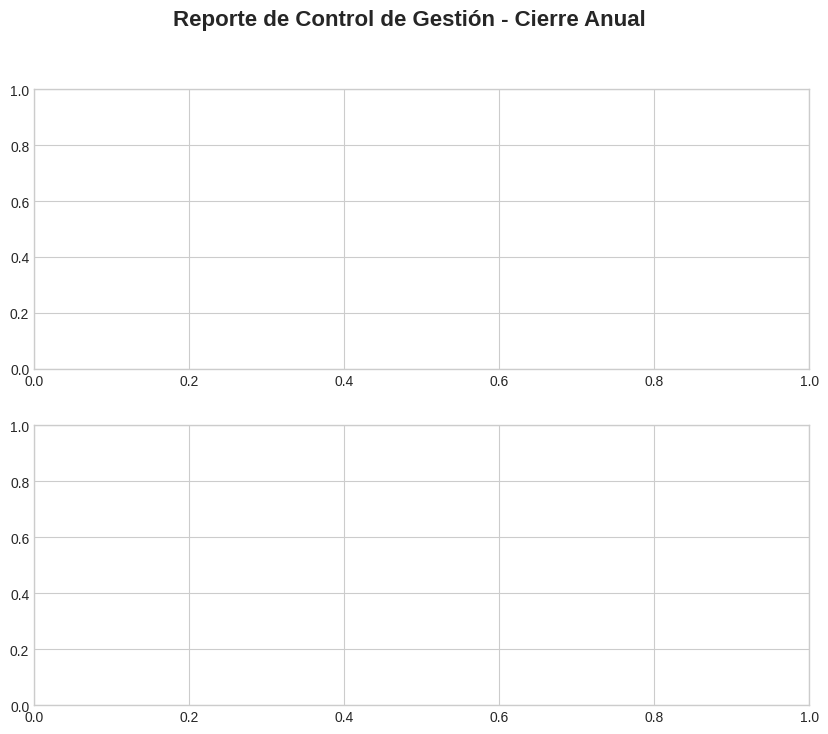

In [4]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 8))
fig.suptitle('Reporte de Control de Gestión - Cierre Anual', fontsize=16, fontweight='bold')

### Subplot Superior: Tendencia de Ingresos

Este sub-gráfico muestra la evolución mensual de los ingresos reales comparados con el presupuesto, utilizando un gráfico de líneas.

In [5]:
ax1 = axes[0]
ax1.plot(meses, ingresos_reales, marker='o', color='#1f77b4', linewidth=2.5, label='Real')
ax1.plot(meses, presupuesto, marker='s', color='#ff7f0e', linestyle='--', linewidth=2, label='Presupuesto')

ax1.set_title('Evolución de Ingresos Anuales (Real vs Presupuesto)', fontsize=13)
ax1.set_ylabel('Miles de USD')
ax1.legend(loc='upper left')
ax1.grid(True, linestyle=':', alpha=0.7)

# Destacar el mes con mayor ingreso
ax1.annotate('Pico de Ventas', xy=('Dic', 250), xytext=('Oct', 230),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=7))

Text(Oct, 230, 'Pico de Ventas')

In [10]:
ax1 = axes[0]
ax1.plot(df_ingresos['Mes'], df_ingresos['Real'], marker='o', color='#1f77b4', linewidth=2.5, label='Real')
ax1.plot(df_ingresos['Mes'], df_ingresos['Presupuesto'], marker='s', color='#ff7f0e', linestyle='--', linewidth=2, label='Presupuesto')

ax1.set_title('Evolución de Ingresos Anuales (Real vs Presupuesto)', fontsize=13)
ax1.set_ylabel('Miles de USD')
ax1.legend(loc='upper left')
ax1.grid(True, linestyle=':', alpha=0.7)

# Destacar el mes con mayor ingreso
ax1.annotate('Pico de Ventas', xy=('Dic', 250), xytext=('Oct', 230),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=7))

Text(Oct, 230, 'Pico de Ventas')

El código para el gráfico de Tendencia de Ingresos:

*   `ax1 = axes[0]`: Selecciona el primer sub-gráfico (eje) de la figura para trabajar en él.
*   `ax1.plot(...)`: Dibuja dos líneas:
    *   `ingresos_reales`: Representa los ingresos reales con marcadores circulares (`marker='o'`), color azul (`#1f77b4`) y una línea más gruesa (`linewidth=2.5`).
    *   `presupuesto`: Representa el presupuesto con marcadores cuadrados (`marker='s'`), color naranja (`#ff7f0e`) y una línea discontinua (`linestyle='--'`).
*   `ax1.set_title(...)`: Establece el título del sub-gráfico.
*   `ax1.set_ylabel('Miles de USD')`: Define la etiqueta del eje Y.
*   `ax1.legend(loc='upper left')`: Muestra la leyenda de las líneas en la esquina superior izquierda.
*   `ax1.grid(True, linestyle=':', alpha=0.7)`: Añade una cuadrícula suave al gráfico.
*   `ax1.annotate(...)`: Agrega una anotación al gráfico para destacar el pico de ventas en 'Dic', con una flecha que apunta a esa posición.

El código para el gráfico de Tendencia de Ingresos ha sido actualizado para usar el `DataFrame df_ingresos`:

*   `ax1.plot(df_ingresos['Mes'], df_ingresos['Real'], ...)`: Ahora se accede a los datos de los ingresos reales y presupuesto directamente desde las columnas del DataFrame.
*   El resto de los elementos (marcadores, colores, etiquetas, etc.) se mantienen igual para la personalización visual del gráfico.

### Subplot Inferior: Desvío por División (Barras)

Este sub-gráfico visualiza el desvío presupuestario de cada división corporativa utilizando un gráfico de barras. Las barras se colorean de verde si el desvío es positivo y rojo si es negativo.

In [6]:
ax2 = axes[1]
# Colores condicionales: verde si el desvío es positivo, rojo si es negativo
colores = ['#2ca02c' if val >= 0 else '#d62728' for val in desvio_presupuesto]

barras = ax2.bar(divisiones, desvio_presupuesto, color=colores, alpha=0.85)

ax2.set_title('Desvío Presupuestario por División Corporativa (%)', fontsize=13)
ax2.set_ylabel('Desvío (%)')
ax2.axhline(0, color='black', linewidth=1.2) # Línea base en 0

# Agregar etiquetas numéricas sobre/bajo cada barra
for barra in barras:
    yval = barra.get_height()
    desplazamiento = 0.5 if yval > 0 else -1
    ax2.text(barra.get_x() + barra.get_width()/2, yval + desplazamiento,
             f'{yval}%', ha='center', va='bottom' if yval > 0 else 'top',
             fontweight='bold', color='black')

El código para el gráfico de Desvío por División:

*   `ax2 = axes[1]`: Selecciona el segundo sub-gráfico (eje).
*   `colores = [...]`: Crea una lista de colores que serán verde si el desvío es positivo y rojo si es negativo.
*   `barras = ax2.bar(...)`: Dibuja un gráfico de barras con `divisiones` en el eje X y `desvio_presupuesto` en el eje Y, usando los `colores` definidos.
*   `ax2.set_title(...)`: Establece el título del sub-gráfico.
*   `ax2.set_ylabel('Desvío (%)')`: Define la etiqueta del eje Y.
*   `ax2.axhline(0, color='black', linewidth=1.2)`: Añade una línea horizontal en 0 para referencia.
*   `for barra in barras: ...`: Itera sobre cada barra para añadir etiquetas de texto con el valor del desvío encima o debajo de cada barra, dependiendo de si es positivo o negativo.

### Nuevo Gráfico: Dispersión (Scatter Plot)

Un gráfico de dispersión es excelente para visualizar la relación entre dos variables numéricas. Aquí, comparamos los `ingresos_reales` con el `presupuesto` para ver qué tan bien se alinean.

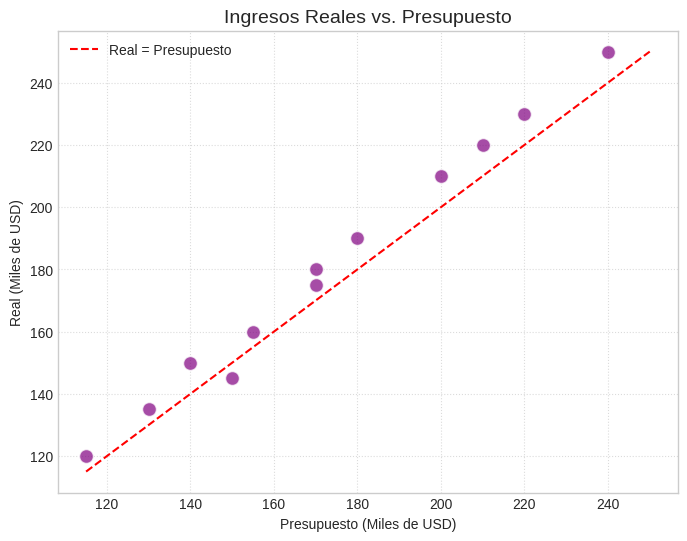

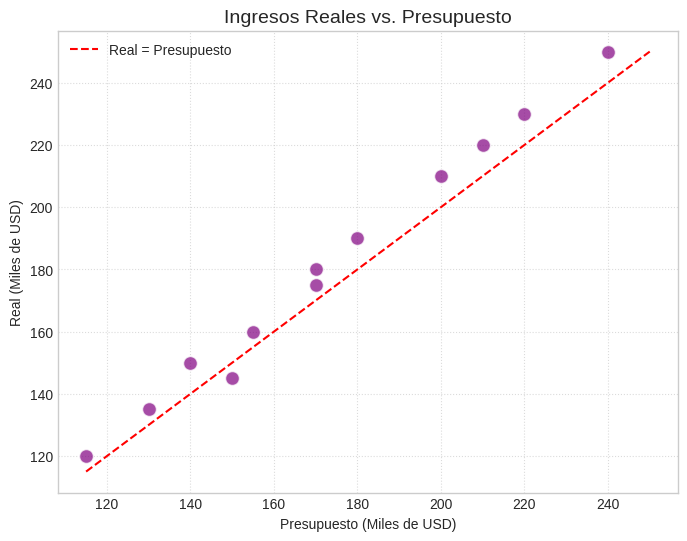

In [11]:
fig_scatter, ax_scatter = plt.subplots(figsize=(8, 6))
ax_scatter.scatter(df_ingresos['Presupuesto'], df_ingresos['Real'], color='purple', alpha=0.7, edgecolors='w', s=100)

# Añadir una línea de referencia para una correspondencia perfecta (Real == Presupuesto)
max_val = max(df_ingresos['Presupuesto'].max(), df_ingresos['Real'].max())
min_val = min(df_ingresos['Presupuesto'].min(), df_ingresos['Real'].min())
ax_scatter.plot([min_val, max_val], [min_val, max_val], 'r--', label='Real = Presupuesto')

ax_scatter.set_title('Ingresos Reales vs. Presupuesto', fontsize=14)
ax_scatter.set_xlabel('Presupuesto (Miles de USD)')
ax_scatter.set_ylabel('Real (Miles de USD)')
ax_scatter.grid(True, linestyle=':', alpha=0.7)
ax_scatter.legend()

fig_scatter # Display the figure

### Nuevo Gráfico: Histograma

Los histogramas son útiles para mostrar la distribución de una única variable numérica. Aquí, visualizamos la distribución de los `ingresos_reales`.

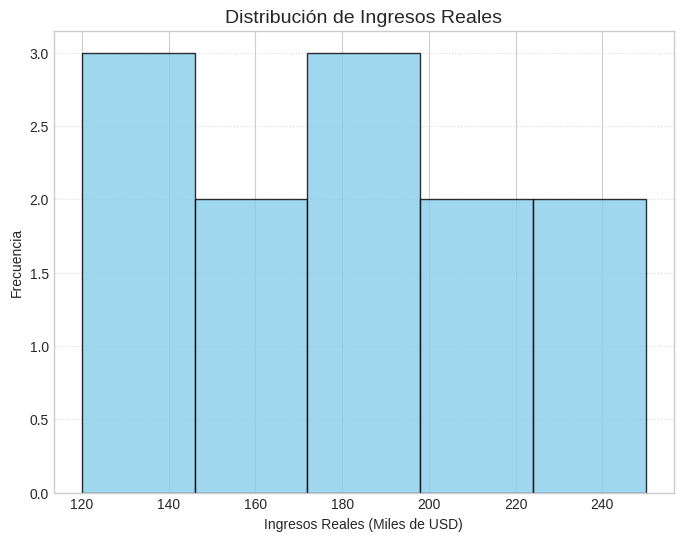

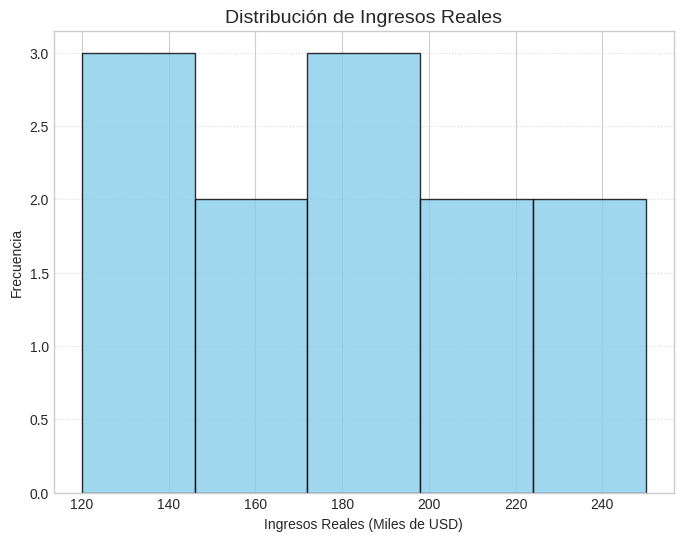

In [12]:
fig_hist, ax_hist = plt.subplots(figsize=(8, 6))
ax_hist.hist(df_ingresos['Real'], bins=5, color='skyblue', edgecolor='black', alpha=0.8)

ax_hist.set_title('Distribución de Ingresos Reales', fontsize=14)
ax_hist.set_xlabel('Ingresos Reales (Miles de USD)')
ax_hist.set_ylabel('Frecuencia')
ax_hist.grid(axis='y', linestyle=':', alpha=0.7)

fig_hist # Display the figure

### Nuevo Gráfico: Torta (Pie Chart)

Los gráficos de torta son ideales para mostrar proporciones de un todo. Crearemos datos de ejemplo para las "Ventas por Categoría de Producto".

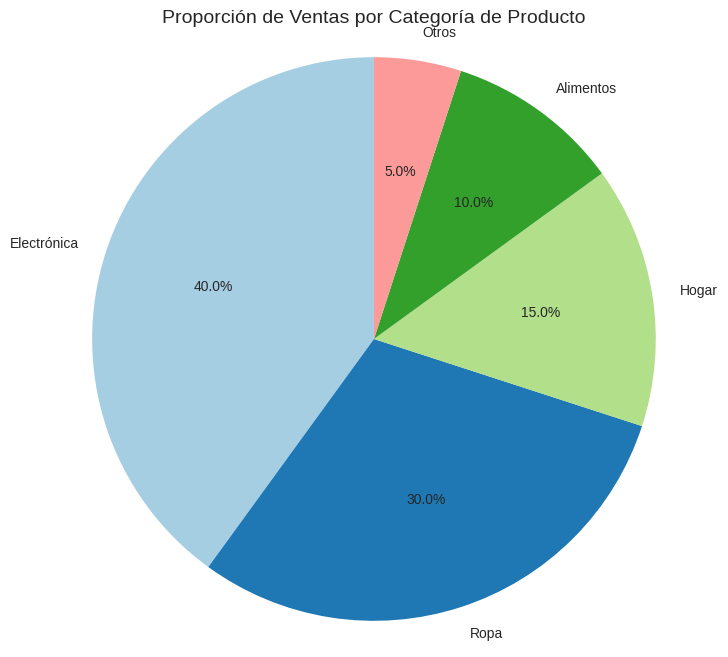

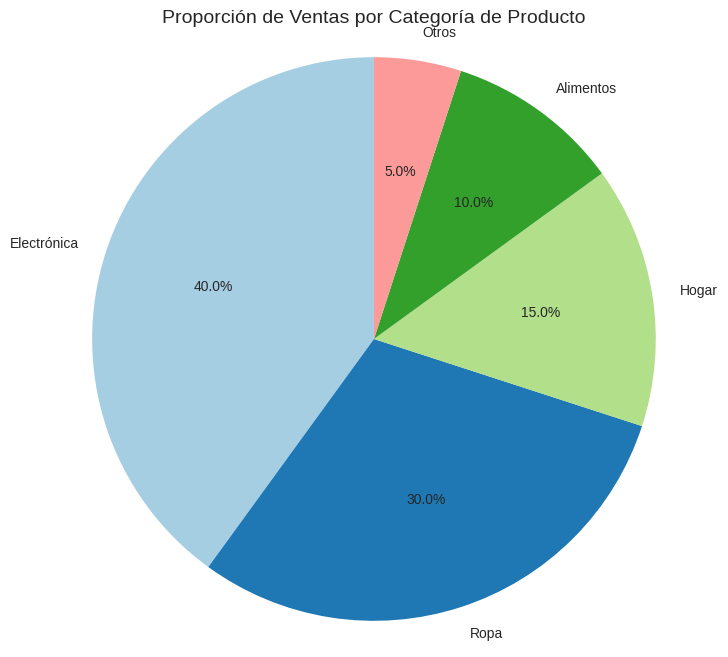

In [13]:
categorias = ['Electrónica', 'Ropa', 'Hogar', 'Alimentos', 'Otros']
ventas = [400, 300, 150, 100, 50]

fig_pie, ax_pie = plt.subplots(figsize=(8, 8))
ax_pie.pie(ventas, labels=categorias, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
ax_pie.axis('equal') # Asegura que el círculo sea un círculo.

ax_pie.set_title('Proporción de Ventas por Categoría de Producto', fontsize=14)

fig_pie # Display the figure

### Nuevo Gráfico: Barras Agrupadas (Grouped Bar Chart)

Los gráficos de barras agrupadas son excelentes para comparar múltiples series de datos dentro de categorías. Aquí, comparamos los ingresos `Real` y `Presupuesto` para cada `Mes`.

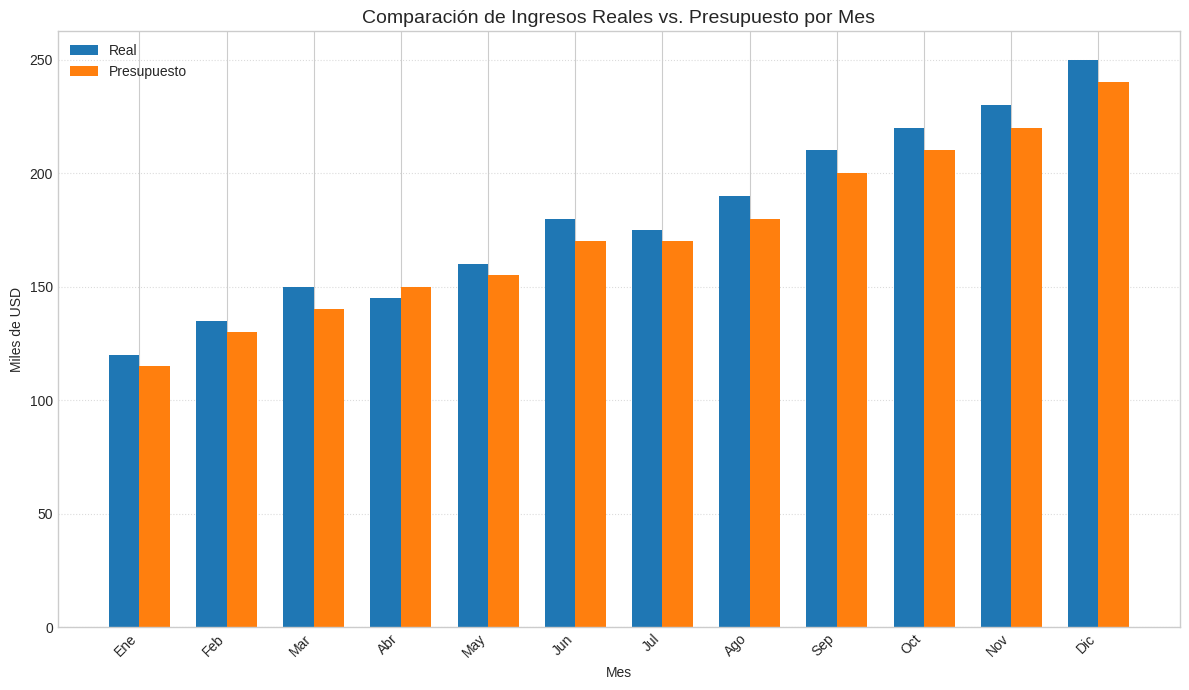

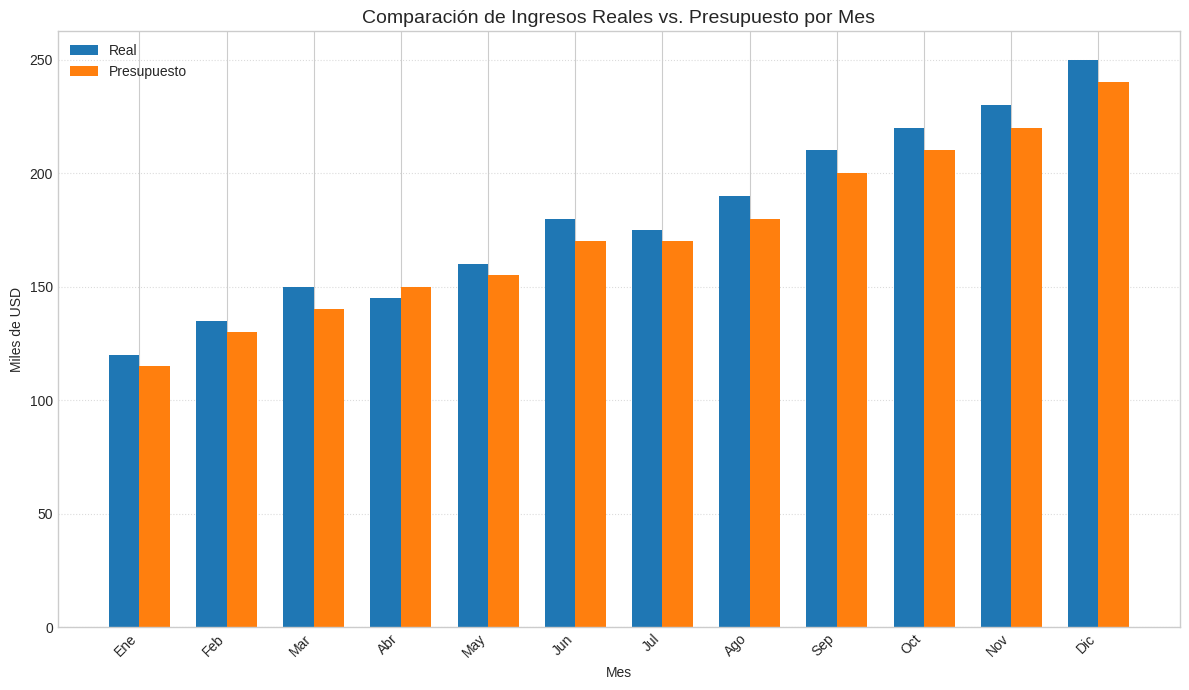

In [14]:
fig_grouped_bar, ax_grouped_bar = plt.subplots(figsize=(12, 7))

bar_width = 0.35
index = np.arange(len(df_ingresos['Mes']))

bar1 = ax_grouped_bar.bar(index - bar_width/2, df_ingresos['Real'], bar_width, label='Real', color='#1f77b4')
bar2 = ax_grouped_bar.bar(index + bar_width/2, df_ingresos['Presupuesto'], bar_width, label='Presupuesto', color='#ff7f0e')

ax_grouped_bar.set_title('Comparación de Ingresos Reales vs. Presupuesto por Mes', fontsize=14)
ax_grouped_bar.set_xlabel('Mes')
ax_grouped_bar.set_ylabel('Miles de USD')
ax_grouped_bar.set_xticks(index)
ax_grouped_bar.set_xticklabels(df_ingresos['Mes'], rotation=45, ha='right')
ax_grouped_bar.legend()
ax_grouped_bar.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()

fig_grouped_bar # Display the figure

### 4. Ajustes Finales y Guardado

Se realizan ajustes finales para asegurar que el diseño del gráfico sea óptimo y se guarda la figura como un archivo PNG.

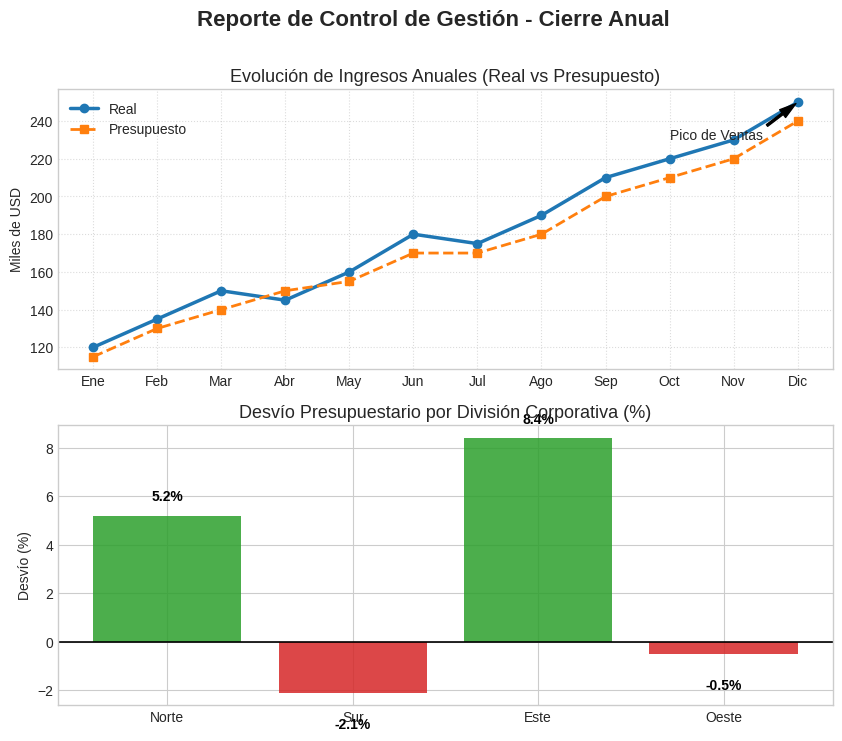

<Figure size 640x480 with 0 Axes>

In [8]:
plt.tight_layout() # Evita que los títulos se superpongan y recorta excesos de margen
plt.savefig('reporte_cierre_clase3.png', dpi=300, bbox_inches='tight')

# Display the figure by leaving it as the last expression in the cell
fig